---
title: "Week 4 (CS 418 @ UIC)"
jupyter: python3
format:
  revealjs:
    fig-format: svg
    fig-width: 5
    fig-height: 3.09
    auto-stretch: false
    footer: '<img src="../assets/branding/uic-black-logo.svg" alt="UIC logo"> <img src="../assets/branding/cc-by-nc-sa-small.svg" alt="CC BY-NC-SA"> <span class="footer-text">CS 418, Intro to Data Science, Week 4</span><span class="footer-text"><a href="https://dodatascience.fun/slides/week4.html">dodatascience.fun/slides/week4</a></span>'
---

In [1]:
#| echo: false
# Shared setup for every figure in this deck.
import numpy as np
import polars as pl
from plotnine import *

ORANGE = "#f9461c"
DARK = "#c83214"
INK = "#1a1a1a"

def note(x, y, text, ha="left", color=INK, size=13):
    """A text annotation in the deck's type and colors."""
    return annotate("text", x=x, y=y, label=text, ha=ha, size=size, color=color)

def upto(df, col, levels, k, on=0.8):
    """Alpha column: `on` for the first k levels of `col`, 0 for the rest.

    Used with scale_alpha_identity() to render a faceted figure several times
    with the later panels blank. Every panel frame and axis is still computed
    from the full data, so overlaying the versions in an .r-stack fills the
    panels in one at a time without the layout shifting.
    """
    return df.with_columns(
        pl.when(pl.col(col).cast(pl.Utf8).is_in(levels[:k]))
          .then(on).otherwise(0.0).alias("a"))

<!-- slide 1 -->
# Week 4 Slide Deck {.course-title}

## Exploratory Analysis; Descriptive Stats

Jack Bandy
2026

---

<!-- slide 2 -->
# Exploratory Data Analysis {.course-title .photo-title data-state="photo-title" background-image="../assets/orange-line-stops-better/stop04-washington-wells-b.jpg" background-size="cover"}

CS 418 · Week 4 · 🟠 Washington/Wells 🟠

---

<!-- slide 3 -->
# Demo Content Slide

Placeholder content for Week 4.

- Exploratory analysis
- Descriptive statistics
- Initial data questions

---

<!-- slide 4 -->
# What is Exploratory Data Analysis?

::: {.incremental}
- Exploratory Data Analysis (EDA) is the process of exploring and analyzing data to better understand it, discover patterns, identify potential issues, and determine the best approach for building predictive models.
- The main tools of exploratory data analysis are:
  - **Summary Statistics** (mean, median, spread, counts)
  - **Visualization** (histograms, box plots, scatter plots)
:::

---

<!-- slide 5 -->
# Exploratory vs. Confirmatory

::: {.incremental}
- EDA was promoted by statistician **John Tukey** as a contrast to **confirmatory data analysis**, which is concerned with modeling and hypothesis testing.
- In EDA, there is **no hypothesis** and **no model**.
- We just want to gain intuition about the data.
:::

---

<!-- slide 6 -->
# Tukey on EDA {.quote-slide}

> "Exploratory data analysis" is an attitude, a state of flexibility, a willingness to look for those things that we believe are not there, as well as those we believe to be there.

::: {.attribution}
John W. Tukey
:::

::: {.quote-source}
*The Collected Works of John W. Tukey*, Vol. IV, ed. Lyle V. Jones (1986), p. 806 — quoted and sourced in [Brillinger, "Data Analysis, Exploratory" (2011)](https://www.stat.berkeley.edu/~brill/Papers/EDASage.pdf)
:::

---

<!-- slide 7 -->
# Before you model, understand your data
::: {.incremental}
- Before running analyses or building any machine learning systems, data scientists **always understand the data**.
- If *you* can't identify a trend or make a prediction for your dataset, neither will an automated algorithm.
- Exploration also gives you ideas for how to represent and clean your data better.
- The right pre-processing can matter more than which algorithm you pick.
:::

---

<!-- slide 8 -->
# Steps

The steps of exploratory data analysis are:

::: {.incremental}
1. Data Collection and Loading (setting up your environment)
2. Summary Statistics (*describe()* using polars)
3. Handling anomalies (e.g. missing data)
4. Understanding the shape of the data
5. Detecting outliers
6. Correlation Analysis
:::

---

<!-- slide 9 -->
# Discovering and handling anomalies
Skipping this step often causes problems downstream

Categories include:

::: {.incremental}
- Missing values (e.g. nulls, N/A, NaN)
- Duplicates (multiple rows with same values)
- Inconsistent formatting (e.g. "yyyy/dd/mm" vs "mm/dd/yyyy")
- Wrong data types (dates stored as strings, numbers stored as strings)
- Invalid values (e.g. age = 350)
- Structure issues (mixed units: miles vs km)
:::

---

<!-- slide 10 -->
# Exploring data with polars
The polars package has built-in exploratory methods:

::: {.incremental}
- `df.shape` — the dimensions of the dataframe (number of rows, number of columns)
- `df.glimpse()` — name, type, and first values of each feature
- `df.null_count()` — how many missing values each feature has
- `df.describe()` — summary statistics (count, null count, mean, standard deviation, min/max, and quartiles) for each feature
:::

```python
import polars as pl
df = pl.read_csv('ages.csv')
print(df.shape)
# (3, 2)
```

---

<!-- slide 11 -->
# Descriptive vs. Inferential Statistics
Statistics deals with the collection, analysis, interpretation, and presentation of data. There are two types of statistical analysis:

::: {.incremental}
- **Descriptive statistics** summarize data about a *sample* drawn from a population.
  - Measures of central tendency (mean, median, mode)
  - Measures of dispersion or spread (range, standard deviation, variance)
- **Inferential statistics** use information from the sample to draw conclusions about the population.
:::

::: {.fragment}
This week is mostly about descriptive statistics.
:::

---

<!-- slide 12 -->
# Descriptive Statistics

::: {.incremental}
- Summarize and describe what's in the data.
- **Center:** Mean, median, mode.
- **Spread:** Maximum, Minimum, Range, Standard deviation, Variance.
- **Position:** Quartiles and percentiles.
:::

---

<!-- slide 13 -->
# Measures of Center

::: {.incremental}
- **Mean** — the average of all the values.
- **Median** — the middle value of the sorted data.
- **Mode** — the most frequent value (can be more than one).
:::

::: {.fragment}
**Example** A = {7, 9, 9, 12, 13}

**Mean =** (7 + 9 + 9 + 12 + 13) / 5 = 10  
**Median =** 9  
**Mode =** 9
:::

---

<!-- slide 14 -->
# Measures of Center ("Central Tendency")

::: {style="font-size:0.6em; font-style:normal; color:#1f8a9b; font-weight:700; margin-top:-0.3em;"}
Using Python
:::

With a polars DataFrame, each measure is one method call:

::: {.incremental}
- `df.mean()` — the mean of every column
- `df.median()` — the median of every column
- `df["grades"].mode()` — the mode (a Series method; there may be more than one)
:::

---

<!-- slide 15 -->
# Measures of Spread

:::: {.columns}
::: {.column width="20%"}

<table style="border-collapse:collapse; margin:0.2em 26px 0 auto;">
<tr><td style="border:2px solid #f9461c; background:#f9461c; color:#fff; font-weight:bold; padding:6px 22px; text-align:center;">Grades</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">24</td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 30px; text-align:center;"><span style="display:inline-block; border:3px solid #1f2d3d; border-radius:50%; width:50px; height:50px; line-height:50px; font-weight:bold;">35</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">32</td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 30px; text-align:center;"><span style="display:inline-block; border:3px solid #1f2d3d; border-radius:50%; width:50px; height:50px; line-height:50px; font-weight:bold;">21</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">28</td></tr>
</table>

::: {style="font-size:0.5em; text-align:center; margin-top:0.6em; line-height:1.6;"}
[Maximum = 35]{style="color:#1f2d3d; font-weight:bold;"}<br>
[Minimum = 21]{style="color:#1f2d3d; font-weight:bold;"}
:::

:::
::: {.column width="80%"}

::: {style="font-size:0.82em;"}
**Maximum** — The largest value in the data set.

**Minimum** — The smallest value in the data set.

**Range** — How far the data stretches, end to end.
:::

::: {style="text-align:center; margin-top:1.2em;"}
$$\text{Range} = \text{Max} - \text{Min} = 35 - 21 = 14$$
:::

:::
::::

---

<!-- slide 16 -->
# Measures of Spread

:::: {.columns}
::: {.column width="20%"}

<table style="border-collapse:collapse; margin:0.2em 26px 0 auto;">
<tr><td style="border:2px solid #f9461c; background:#f9461c; color:#fff; font-weight:bold; padding:6px 22px; text-align:center;">Grades</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">24</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">35</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">32</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">21</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">28</td></tr>
</table>

::: {style="font-size:0.5em; text-align:right; margin-top:0.6em; line-height:1.6;"}
[Variance = 32.5]{style="color:#000000; font-weight:bold;"}<br>
[Standard Deviation ≈ 5.7]{style="color:#000000; font-weight:bold;"}
:::

:::
::: {.column width="80%"}

::: {style="font-size:0.82em;"}
**Standard deviation** — The typical distance from the mean (in the data's own units).

**Variance** — The variance of a dataset is the square of the standard deviation.

Mean $\bar{x} = 28$.
:::

::: {style="text-align:center; margin-top:1.2em;"}
$$\begin{aligned}
s^2 &= \frac{\sum (a_i-\bar{x})^2}{n-1} = \frac{130}{4} = 32.5 \\[6pt]
s &= \sqrt{32.5} \approx 5.7
\end{aligned}$$
:::

:::
::::

---

<!-- slide 17 -->
# Measures of Position 

:::: {.columns}

::: {.column width="32%"}
<table style="border-collapse:collapse; margin:0.4em auto 0;">
<tr><td style="border:2px solid #f9461c; background:#f9461c; color:#fff; font-weight:bold; padding:6px 24px; text-align:center;">Grades (sorted)</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 24px; text-align:center;">21</td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 24px; text-align:center;"><span style="display:inline-block; border:3px solid #001E62; border-radius:50%; width:50px; height:50px; line-height:50px; color:#1f2d3d; font-weight:bold;">24</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 24px; text-align:center;"><span style="display:inline-block; border:3px solid #001E62; border-radius:50%; width:50px; height:50px; line-height:50px; color:#1f2d3d; font-weight:bold;">28</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 24px; text-align:center;"><span style="display:inline-block; border:3px solid #001E62; border-radius:50%; width:50px; height:50px; line-height:50px; color:#1f2d3d; font-weight:bold;">32</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 24px; text-align:center;">35</td></tr>
</table>
:::

::: {.column width="68%"}

::: {style="font-size:0.8em;"}
**Percentiles** divide a dataset into 100 equal parts such that n% of the data is less than or equal to the nth percentile.

**Quartiles** divide a dataset into quarters.

- First quartile (Q1) = 25% or less of the data.
- Second quartile (Q2) = 50% or less of the data / Median.
- Third quartile (Q3) = 75% or less of the data.
:::

<div style="text-align:center; margin-top:0.6em;">
<span style="display:inline-block; border:2px solid #001E62; border-radius:6px; padding:6px 18px; margin:0 6px; font-weight:bold; color:#1f2d3d;">Q1 = 24</span>
<span style="display:inline-block; border:2px solid #001E62; border-radius:6px; padding:6px 18px; margin:0 6px; font-weight:bold; color:#1f2d3d;">Q2 = 28</span>
<span style="display:inline-block; border:2px solid #001E62; border-radius:6px; padding:6px 18px; margin:0 6px; font-weight:bold; color:#1f2d3d;">Q3 = 32</span>
</div>
:::

::::

---

<!-- slide 18 -->
# The Five-Number Summary

::: {.incremental}
- The minimum, **Q1**, the median (**Q2**), **Q3**, and the maximum together form a set of descriptive statistics called the **five-number summary**.
- The **interquartile range (IQR)** is $Q3 - Q1$ : the range covered by the middle 50% of the data.
- These five numbers are exactly what a **box plot** draws.
:::

---

<!-- slide 19 -->
# Detecting Outliers
::: {.incremental}
- An **outlier** is a value much larger or much smaller than the rest of the data.
- The common rule: a point is an outlier if it falls more than **1.5 × IQR** below Q1 or above Q3.
  - Some implementations use 3 × IQR, or other cutoffs (1.5 is a convention, not a law)
- Box plots are useful for summarizing a distribution *and* for comparing several distributions side by side.
- Outliers are not automatically errors. Investigate before you delete.
:::

---

<!-- slide 20 -->
# Anatomy of a Box Plot {.figure-slide}

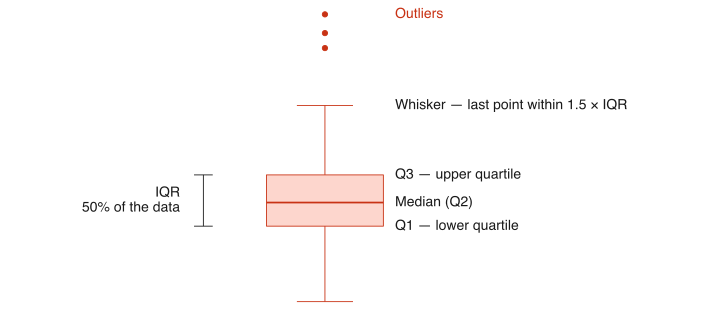

In [2]:
#| echo: false
#| fig-alt: 'A single vertical box plot annotated with its parts: the box spanning Q1 to Q3 labelled as the interquartile range holding 50% of the data, the median line inside it, whiskers reaching the last points within 1.5 times the IQR, and three outlier dots above the upper whisker'
rng = np.random.default_rng(7)
vals = np.concatenate([rng.normal(30, 11, 220), [70, 74, 79]])
q1, med, q3 = np.percentile(vals, [25, 50, 75])
iqr = q3 - q1
lo = vals[vals >= q1 - 1.5 * iqr].min()
hi = vals[vals <= q3 + 1.5 * iqr].max()
box = pl.DataFrame({"x": np.zeros(len(vals)), "v": vals})

(ggplot(box, aes("x", "v"))
 + geom_boxplot(width=0.5, fill=ORANGE, alpha=0.22, color=DARK,
                outlier_color=DARK, outlier_size=2.5)
 + annotate("segment", x=-0.12, xend=0.12, y=lo, yend=lo, color=DARK)
 + annotate("segment", x=-0.12, xend=0.12, y=hi, yend=hi, color=DARK)
 + annotate("segment", x=-0.52, xend=-0.52, y=q1, yend=q3, color=INK)
 + annotate("segment", x=-0.56, xend=-0.48, y=q1, yend=q1, color=INK)
 + annotate("segment", x=-0.56, xend=-0.48, y=q3, yend=q3, color=INK)
 + note(-0.62, (q1 + q3) / 2, "IQR\n50% of the data", ha="right", size=14)
 + note(0.3, q3, "Q3 — upper quartile", size=14)
 + note(0.3, med, "Median (Q2)", size=14)
 + note(0.3, q1, "Q1 — lower quartile", size=14)
 + note(0.3, hi, "Whisker — last point within 1.5 × IQR", size=14)
 + note(0.3, vals.max(), "Outliers", color=DARK, size=14)
 + scale_x_continuous(limits=(-1.25, 1.55))
 + theme_void()
 + theme(figure_size=(10, 4.4)))

---

<!-- slide 22 -->
# Data Visualization {.section-header}

---

<!-- slide 23 -->
#  Kinds of Visualization

::: {.incremental}
- **Exploratory Data Visualization:** figuring out what is true. Mostly for you.
- **Persuasive Data Visualization:** convincing other people something is true. Polished, for an audience.
:::

::: {.fragment style="margin-top:1em;"}
This week is mostly about exploratory visualization.
:::

---

<!-- slide 24 -->
# Choosing a Plot: Quantitative Data

**Plots:** histograms, box plots, rug plots, smoothed interpolations (KDE — kernel density estimators)

::: {.incremental}
- **Histogram** — relative frequency of values; there's a tradeoff in choosing bin sizes.
- **Rug plot** — shows where the actual data points sit.
- **KDE plot** — a smoothed density estimate; there's a tradeoff in the "bandwidth" parameter.
:::

::: {.fragment style="margin-top:0.8em;"}
**Look for:** spread, shape, modes, gaps, outliers, unreasonable values.
:::

---

<!-- slide 25 -->
# Some Made-Up Data

In [3]:
#| echo: true
rng = np.random.default_rng(418)
d = np.concatenate([rng.normal(5, 3, 45), rng.normal(30, 6, 170),
                    rng.normal(80, 3, 7)])
dist = pl.DataFrame({"v": d})

::: {style="font-size:0.8em; margin-top:0.4em;"}
Three groups together: a small one near 5, a big one near 30, and seven near 80.
:::

---

<!-- slide 26 -->
# Histogram {.code-figure-slide}

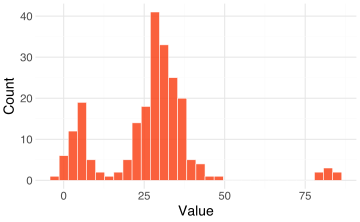

In [4]:
#| echo: true
#| fig-alt: "Histogram of the made-up data with 32 bins, showing a small mode near 5, a large mode near 30, and a few isolated bars near 80"
(ggplot(dist, aes("v"))
 + geom_histogram(bins=32, fill=ORANGE, alpha=0.85,
                  color="white", size=0.3)
 + labs(x="Value", y="Count")
 + theme_minimal(base_size=14))

::: {style="font-size:0.8em;"}
Counts values falling in each bin. `bins` is the main knob to adjust.
:::

---

<!-- slide 27 -->
# Too Few Bins {.code-figure-slide}

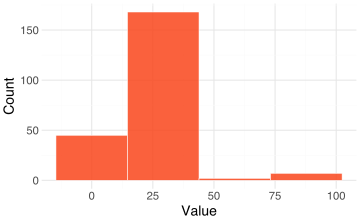

In [5]:
#| echo: true
#| fig-alt: "Histogram of the same data with only 4 bins, collapsing the two groups into one tall bar and hiding the gap before the outliers"
(ggplot(dist, aes("v"))
 + geom_histogram(bins=4, fill=ORANGE, alpha=0.85,
                  color="white", size=0.3)
 + labs(x="Value", y="Count")
 + theme_minimal(base_size=14))

::: {style="font-size:0.8em;"}
**Oversmoothed.** The two groups merge into one bar, and the gap before the outliers disappears. The shape looks simpler than the data actually is.
:::

---

<!-- slide 28 -->
# Too Many Bins {.code-figure-slide}

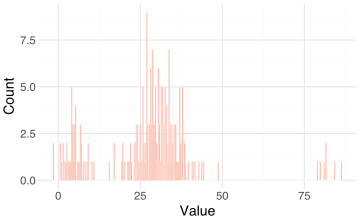

In [6]:
#| echo: true
#| fig-alt: "Histogram of the same data with 300 bins, producing a spiky comb of mostly one- and two-count bars where the overall shape is hard to see"
(ggplot(dist, aes("v"))
 + geom_histogram(bins=300, fill=ORANGE, alpha=0.85,
                  color="white", size=0.3)
 + labs(x="Value", y="Count")
 + theme_minimal(base_size=14))

::: {style="font-size:0.8em;"}
**Undersmoothed.** Most bins hold one or two points, so the bars mostly report sampling noise. The modes are in there, but you have to squint past the comb to find them.
:::

---

<!-- slide 29 -->
# Rug Plot {.code-figure-slide}

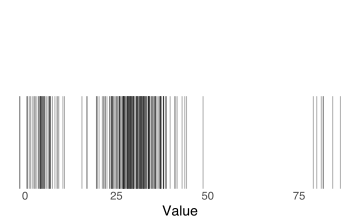

In [7]:
#| echo: true
#| fig-alt: "Rug plot of the made-up data: a dense band of tick marks near 30, a sparser band near 5, an empty stretch, and a handful of ticks near 80"
(ggplot(dist, aes("v", 0))
 + geom_rug(sides="b", color=INK, alpha=0.4, length=0.5)
 + labs(x="Value")
 + theme_minimal(base_size=14)
 + theme(panel_grid=element_blank(),
         axis_title_y=element_blank(),
         axis_text_y=element_blank()))

::: {style="font-size:0.8em;"}
One tick per data point (no binning, no smoothing). Great for spotting gaps and outliers; less helpful once the ticks overlap into a solid block.
:::

---

<!-- slide 30 -->
# KDE Plot {.code-figure-slide}

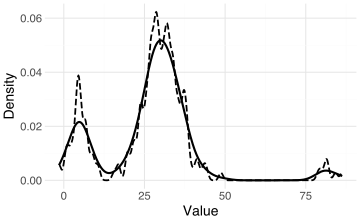

In [8]:
#| echo: true
#| fig-alt: "Two kernel density curves over the same data: a smooth solid curve with two clear modes, and a wigglier dashed curve from a smaller bandwidth"
(ggplot(dist, aes("v"))
 + geom_density(size=1.2)                   # default bandwidth
 + geom_density(alpha=0.6, size=1.0, linetype="dashed",
                adjust=0.25)                              # 1/4 the bandwidth
 + labs(x="Value", y="Density")
 + theme_minimal(base_size=14))

::: {style="font-size:0.8em;"}
A smoothed estimate of the density. **`adjust` scales the bandwidth:** the dashed curve is wigglier and chases noise, the solid one may smooth real structure away.
:::

---

<!-- slide 31 -->
# All Three at Once {.figure-slide}

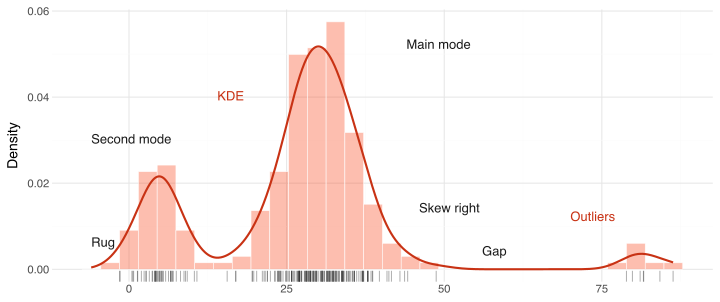

In [9]:
#| echo: false
#| fig-alt: A histogram of a bimodal distribution with a kernel density curve drawn over it and a rug of individual points along the bottom axis, annotated to point out the main mode, a second mode, a right skew, a gap, and a cluster of outliers
(ggplot(dist, aes("v"))
 + geom_histogram(aes(y=after_stat("density")), bins=32,
                  fill=ORANGE, alpha=0.35, color="white", size=0.3)
 + geom_density(color=DARK, size=1.2)
 + geom_rug(color=INK, alpha=0.4, length=0.04)
 + note(44, 0.052, "Main mode")
 + note(-6, 0.030, "Second mode")
 + note(46, 0.014, "Skew right")
 + note(56, 0.004, "Gap")
 + note(70, 0.012, "Outliers", color=DARK)
 + note(14, 0.040, "KDE", color=DARK)
 + note(-6, 0.006, "Rug")
 + labs(y="Density")
 + theme_minimal(base_size=14)
 + theme(axis_title_x=element_blank(), figure_size=(10, 4.2)))

---

<!-- slide 32 -->
# Choosing a Plot: Categorical Data
**Plots:** bar plots, sorted by frequency or by the ordinal dimension

::: {.incremental}
- **Look for:** skew, frequent and rare categories, invalid categories.
- Consider grouping rare categories together and repeating the analysis.
- For **ordinal** data (e.g. education level: < 12th, HS, Trade, Some College, College), keep the natural order — don't sort bars shortest to tallest.
- **Dot plots** (Cleveland dot plots) make it easier to compare values than bars do.
:::

::: {.fragment style="font-size:0.85em; margin-top:0.6em;"}
Bar *width* has no meaning. Only length encodes the value.
:::

---

<!-- slide 33 -->
# Bar Plot (for an Ordinal Variable) {.figure-slide}

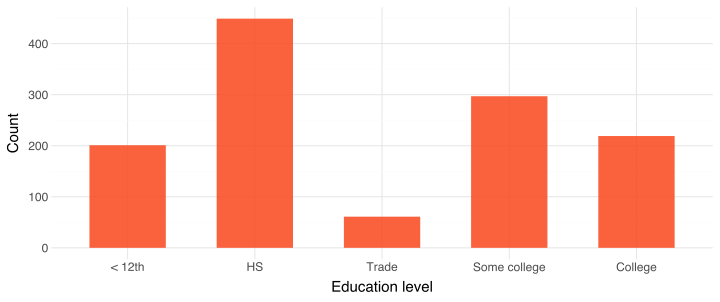

In [10]:
#| echo: false
#| fig-alt: Bar chart of mothers' education level with five bars in their natural order from less than 12th grade through college; high school is the tallest bar and trade school the shortest
levels = ["< 12th", "HS", "Trade", "Some college", "College"]
edu = pl.DataFrame({
    "level": levels,
    "count": [201, 449, 61, 297, 219],
}).with_columns(pl.col("level").cast(pl.Enum(levels)))

(ggplot(edu, aes("level", "count"))
 + geom_col(fill=ORANGE, alpha=0.85, width=0.6)
 + labs(x="Education level", y="Count")
 + theme_minimal(base_size=15)
 + theme(figure_size=(10, 4.2)))

::: {style="font-size:0.6em; margin-top:0.2em;"}
The bars keep the natural order of the levels, not shortest-to-tallest.
:::

---

<!-- slide 34 -->
# Lollipop Chart of the Same Data {.figure-slide}

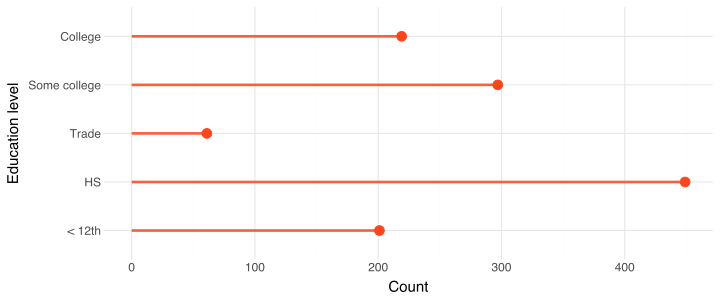

In [11]:
#| echo: false
#| fig-alt: Lollipop chart of the same five education-level counts, with one dot per level at the end of an orange stem running out from the axis, which can make the values easier to compare than the bars
(ggplot(edu, aes("count", "level"))
 + geom_segment(aes(x=0, xend="count", y="level", yend="level"),
                color=ORANGE, size=1.5, alpha=0.85)
 + geom_point(color=ORANGE, size=5)
 + labs(x="Count", y="Education level")
 + theme_minimal(base_size=15)
 + theme(figure_size=(10, 4.2)))

::: {style="font-size:0.6em; margin-top:0.2em;"}
Same numbers as the bars, far less ink. The stem carries the value; the dot marks where it ends.
:::

---

<!-- slide 35 -->
# Describing the Shape of Data
Many models assume features are **symmetric** and **unimodal**. Deviations can affect the validity of the model.

::: {.incremental}
- **Symmetric** — looks the same on the left and right sides.
- **Skewed** — one tail is longer than the other (right-skewed, left-skewed).
- **Unimodal** — a single mode (peak).
- **Multimodal** — multiple modes (peaks).
:::

::: {.fragment style="margin-top:0.8em;"}
Histograms are the tool for exploring shape.
:::

---

<!-- slide 36 -->
# Three Shapes {.figure-slide}

In [12]:
#| echo: false
rng = np.random.default_rng(1848)
shapes = ["Symmetric, unimodal", "Right-skewed", "Multimodal"]
shape_df = pl.DataFrame({
    "v": np.concatenate([
        rng.normal(0, 1, 600),
        rng.exponential(1, 600),
        np.concatenate([rng.normal(-2, 0.6, 300), rng.normal(2, 0.6, 300)]),
    ]),
    "shape": np.repeat(shapes, 600),
}).with_columns(pl.col("shape").cast(pl.Enum(shapes)))

def shape_plot(k):
    return (ggplot(upto(shape_df, "shape", shapes, k), aes("v"))
     + geom_histogram(aes(alpha="a"), bins=28, fill=ORANGE,
                      color="white", size=0.3)
     + scale_alpha_identity()
     + facet_wrap("shape", scales="free_x")
     + labs(y="Count")
     + theme_minimal(base_size=15)
     + theme(axis_title_x=element_blank(),
             strip_text=element_text(size=16, color=INK),
             panel_spacing=0.06, figure_size=(10, 4)))

::: {.r-stack}

::: {.fragment .fade-out fragment-index=1}

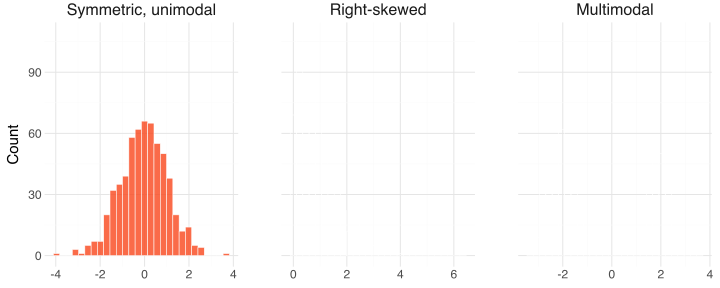

In [13]:
#| echo: false
#| fig-alt: Three histogram panels side by side; only the first is filled in, showing a symmetric unimodal bell shape
shape_plot(1)

:::

::: {.fragment .fade-in-then-out fragment-index=1}

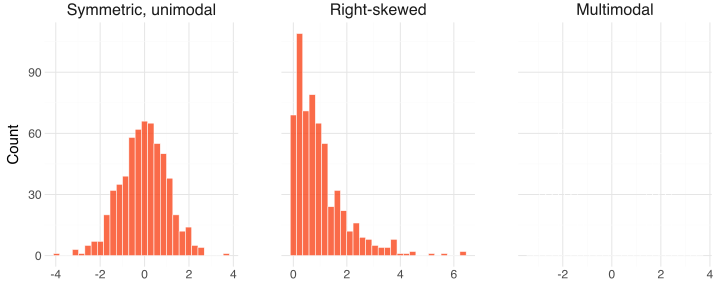

In [14]:
#| echo: false
#| fig-alt: 'The same three panels with the first two filled in: a symmetric bell shape and a right-skewed distribution with a long tail to the right'
shape_plot(2)

:::

::: {.fragment fragment-index=2}

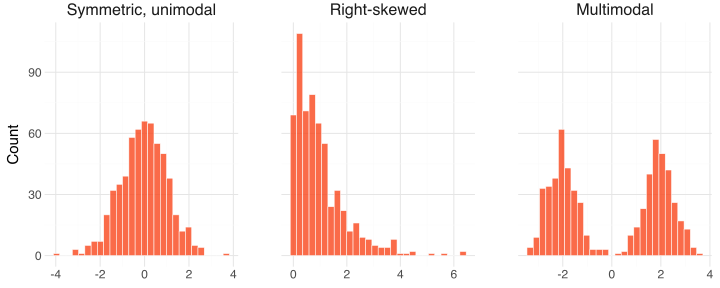

In [15]:
#| echo: false
#| fig-alt: 'All three panels filled in: a symmetric unimodal bell shape, a right-skewed distribution with a long tail to the right, and a multimodal distribution with two separated peaks'
shape_plot(3)

:::

:::

---

<!-- slide 37 -->
# Identifying Relationships
::: {.incremental}
- Features in a dataset are usually related to each other. **Linear** relationships are the simplest type.
- **Correlation** describes the *strength* and *direction* of a linear relationship between two features.
  - **Positive** correlation — one feature increases as the other increases.
  - **Negative** correlation — one feature decreases as the other increases.
- We explore relationships using **scatter plots**: positive correlation, negative correlation, or no linear correlation.
:::

---

<!-- slide 38 -->
# Three Scatter Plots {.figure-slide}

In [16]:
#| echo: false
rng = np.random.default_rng(418)
x = rng.uniform(0, 10, 90)
kinds = ["Positive correlation", "Negative correlation", "No linear correlation"]
corr_df = pl.DataFrame({
    "x": np.tile(x, 3),
    "y": np.concatenate([x + rng.normal(0, 1.5, 90),
                         -x + rng.normal(0, 1.5, 90),
                         rng.uniform(0, 10, 90)]),
    "kind": np.repeat(kinds, 90),
}).with_columns(pl.col("kind").cast(pl.Enum(kinds)))

def corr_plot(k):
    return (ggplot(upto(corr_df, "kind", kinds, k, on=0.75), aes("x", "y"))
     + geom_point(aes(alpha="a"), color=ORANGE, size=2.5)
     + scale_alpha_identity()
     + facet_wrap("kind", scales="free_y")
     + theme_minimal(base_size=15)
     + theme(axis_title=element_blank(), axis_text=element_blank(),
             strip_text=element_text(size=16, weight="bold", color=INK),
             panel_spacing=0.06, figure_size=(10, 4)))

::: {.r-stack}

::: {.fragment .fade-out fragment-index=1}

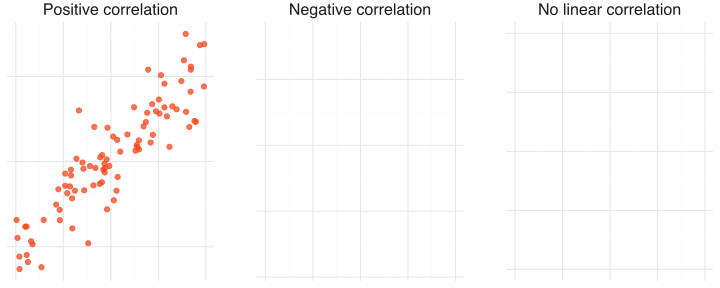

In [17]:
#| echo: false
#| fig-alt: Three scatter plot panels side by side; only the first has points, trending upward for positive correlation
corr_plot(1)

:::

::: {.fragment .fade-in-then-out fragment-index=1}

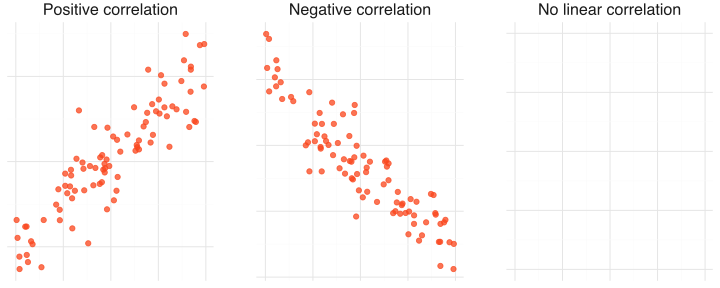

In [18]:
#| echo: false
#| fig-alt: 'The same three panels with the first two filled in: points trending upward, then points trending downward for negative correlation'
corr_plot(2)

:::

::: {.fragment fragment-index=2}

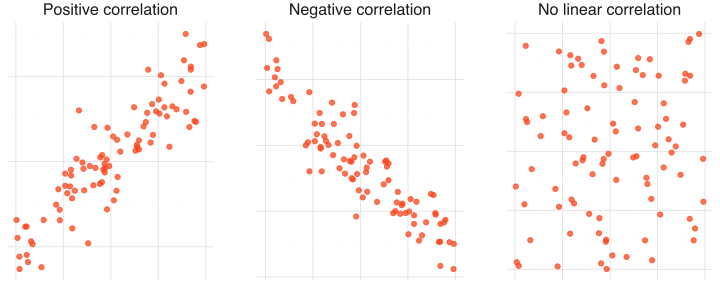

In [19]:
#| echo: false
#| fig-alt: 'All three panels filled in: points trending upward (positive correlation), points trending downward (negative correlation), and points with no visible trend (no linear correlation)'
corr_plot(3)

:::

:::

---

<!-- slide 39 -->
# Correlation Coefficient

The correlation coefficient measures the linear relationship between two features $X$ and $Y$. We'll look at **Pearson's correlation coefficient** first.

::: {.incremental}
- The value is always between **-1 and 1**.
- The sign gives the direction; the closer to -1 or 1, the **stronger** the relationship.
- A coefficient of **0** means there is no *linear* relationship — which is not the same as no relationship at all.
:::

---

<!-- slide 40 -->
# Setup: Chicago 'L' ridership, 2019

Are stations that are busy on weekdays also busy on Saturdays?

In [20]:
#| echo: true
cta = pl.read_csv("../../datasets/cta-ridership/Station_Entries_-_Daily_Totals_20260527.csv",
                  ignore_errors=True)
cta = cta.with_columns(pl.col("rides").str.replace_all(",", "").cast(pl.Int64))
by_day = (cta.filter(pl.col("date").str.ends_with("2019"))
             .group_by("stationname", "daytype")
             .agg(pl.col("rides").median()))
stations = by_day.pivot("daytype", index="stationname", values="rides")

::: {style="font-size:0.8em; margin-top:0.4em;"}
`daytype` is `W` for weekdays, `A` for Saturdays, `U` for Sundays and holidays.
:::

---

<!-- slide 41 -->
# Weekday vs. Saturday {.code-figure-slide}

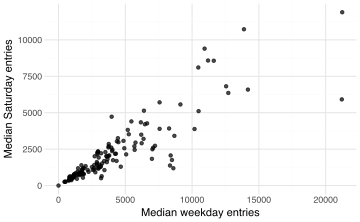

In [21]:
#| echo: true
#| fig-alt: "Scatter plot of 144 Chicago 'L' stations, median weekday entries on the x-axis against median Saturday entries on the y-axis, showing a strong upward linear trend"
(ggplot(stations, aes("W", "A"))
 + geom_point(alpha=0.7)
 + labs(x="Median weekday entries", y="Median Saturday entries")
 + theme_minimal())

---

<!-- slide 42 -->
# How strong is it?

In [22]:
#| echo: true
stations.select(pl.corr("W", "A")).item()

0.8733410513708642

::: {style="font-size:0.85em; margin-top:0.8em;"}
Strong and positive: busy stations are busy on both days. Not *perfect* — Loop stations serving commuters drop off far more on a Saturday than neighborhood stations do.
:::

---

<!-- slide 43 -->
# Setup: Cook County home sales, 2025

Do bigger houses sell for more money?

In [23]:
#| echo: true
sales = pl.read_csv("../../datasets/cook-county-home-sales-2025/cook-county-home-sales-2025.csv",
                    ignore_errors=True)
homes = sales.filter(
    (pl.col("property_group") == "Single-Family")   # condos have no sqft
    & (pl.col("is_multisale") == False)             # one price per home
    & (pl.col("sale_price") > 10_000)               # drop nominal transfers
    & pl.col("building_sqft").is_not_null()
)
homes.height

24775

::: {style="font-size:0.8em; margin-top:0.4em;"}
Three filters before a single plot. Each one is a decision about what counts as a "home sale."
:::

---

<!-- slide 44 -->
# Square Footage vs. Price {.code-figure-slide .build-slide}

::: {.r-stack}

::: {.fragment .fade-out fragment-index=1}

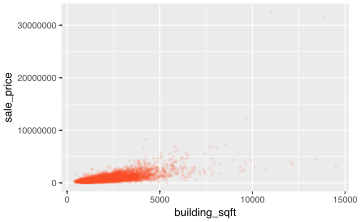

In [24]:
#| echo: true
#| fig-alt: "Scatter plot of Cook County home sales, square footage against sale price, drawn with default styling so a few multi-million-dollar sales stretch the y-axis and flatten the rest of the cloud"
(ggplot(homes, aes("building_sqft", "sale_price"))
 + geom_point(color="#f9461c", alpha=0.08, size=0.8, raster=True))

:::

::: {.fragment .fade-in-then-out fragment-index=1}

/Users/jackb/GitHub/data-science-fun/docs/slides/.venv/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 371 rows containing missing values.


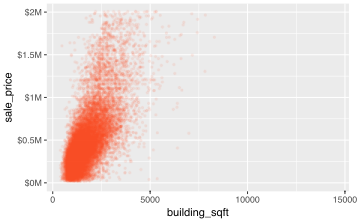

In [25]:
#| echo: true
#| fig-alt: "The same scatter plot with the y-axis limited to two million dollars, which spreads the bulk of the sales out over the full height of the panel"
(ggplot(homes, aes("building_sqft", "sale_price"))
 + geom_point(color="#f9461c", alpha=0.08, size=0.8, raster=True)
 + scale_y_continuous(limits=(0, 2_000_000),
                      labels=lambda v: [f"${x/1e6:g}M" for x in v]))

:::

::: {.fragment .fade-in-then-out fragment-index=2}

/Users/jackb/GitHub/data-science-fun/docs/slides/.venv/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 393 rows containing missing values.


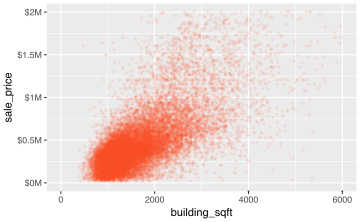

In [26]:
#| echo: true
#| fig-alt: "The same scatter plot with both axes cropped, to two million dollars and six thousand square feet, bringing the cone shape of the main cloud into view"
(ggplot(homes, aes("building_sqft", "sale_price"))
 + geom_point(color="#f9461c", alpha=0.08, size=0.8, raster=True)
 + scale_y_continuous(limits=(0, 2_000_000),
                      labels=lambda v: [f"${x/1e6:g}M" for x in v])
 + scale_x_continuous(limits=(0, 6000)))

:::

::: {.fragment .fade-in-then-out fragment-index=3}

/Users/jackb/GitHub/data-science-fun/docs/slides/.venv/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 393 rows containing missing values.


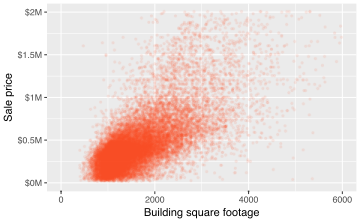

In [27]:
#| echo: true
#| fig-alt: "The same cropped scatter plot, now with the axes labelled building square footage and sale price"
(ggplot(homes, aes("building_sqft", "sale_price"))
 + geom_point(color="#f9461c", alpha=0.08, size=0.8, raster=True)
 + scale_y_continuous(limits=(0, 2_000_000),
                      labels=lambda v: [f"${x/1e6:g}M" for x in v])
 + scale_x_continuous(limits=(0, 6000))
 + labs(x="Building square footage", y="Sale price"))

:::

::: {.fragment fragment-index=4}

/Users/jackb/GitHub/data-science-fun/docs/slides/.venv/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 393 rows containing missing values.


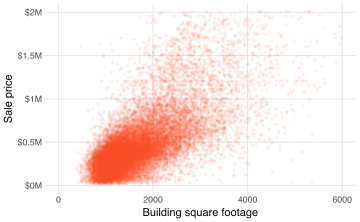

In [28]:
#| echo: true
#| fig-alt: "Scatter plot of about 24,800 Cook County single-family home sales, building square footage on the x-axis against sale price on the y-axis, showing an upward trend that fans out widely at larger sizes"
(ggplot(homes, aes("building_sqft", "sale_price"))
 + geom_point(color="#f9461c", alpha=0.08, size=0.8, raster=True)
 + scale_y_continuous(limits=(0, 2_000_000),
                      labels=lambda v: [f"${x/1e6:g}M" for x in v])
 + scale_x_continuous(limits=(0, 6000))
 + labs(x="Building square footage", y="Sale price")
 + theme_minimal())

:::

:::

---

<!-- slide 45 -->
# How strong is it?

In [29]:
#| echo: true
homes.select(pl.corr("building_sqft", "sale_price")).item()

0.6732009189834515

::: {style="font-size:0.85em; margin-top:0.8em;"}
Positive, but weaker than the CTA example (0.88).
:::

---

<!-- slide 46 -->
# The Cone Shape
::: {.incremental}
- The points **fan out** as houses get larger
    - Small homes cluster in a narrow price band, large homes are all over
- A single correlation coefficient reports one number for the whole cloud, and hides that the relationship is much tighter at one end than the other.
- Always look at the scatter plot.
- **The coefficient is only a summary.**
:::

::: {.fragment style="font-size:0.85em; margin-top:0.6em;"}
The plot above also hides 393 sales — those above \$2M or over 6,000 sq. ft. — which we cropped off the axes. They are still in the correlation.
:::

---

<!-- slide 47 -->
# Concluding Notes
::: {.fragment}
**One-dimensional data**

- Summarize with summary statistics (mean, standard deviation, max, min, quartiles).
- Visualize the distribution with histograms and box plots.
:::

::: {.fragment}
**Two-dimensional data**

- Visualize the relationship with scatter plots.
- Measure the relationship by computing correlations.
:::

::: {.fragment}
**High-dimensional data**

- Create a **scatterplot matrix** showing all pairwise scatter plots.
- Create a **correlation matrix** showing all pairwise correlations.
:::

---

<!-- slide 48 -->
# Sources {.sources}

1. GitHub source: <https://github.com/jackbandy/data-science-fun/blob/main/docs/slides/week4.qmd>.
1. Last modified and compiled August 1, 12:23h Central (Chicago) time.
2. Slides developed using materials from [Elena Zheleva](https://www.cs.uic.edu/~elena/) and [Gonzalo Bello Lander](https://cs.uic.edu/profiles/gonzalo-bello/), the Berkeley DS 100 team, Marine Carpuat, and Brian Ziebart.
3. Tukey quotation: John W. Tukey, *The Collected Works of John W. Tukey, Volume IV: Philosophy and Principles of Data Analysis 1965–1986*, ed. Lyle V. Jones (Wadsworth & Brooks/Cole, 1986), p. 806. Quoted with its page citation in David R. Brillinger, ["Data Analysis, Exploratory," *Encyclopedia of Political Science* (SAGE, 2011), pp. 530–535](https://www.stat.berkeley.edu/~brill/Papers/EDASage.pdf).
4. Slide deck built with [Quarto](https://quarto.org/) revealjs.
5. Title font is Big Shoulders; Body font is [Libre Franklin](https://en.wikipedia.org/wiki/Franklin_Gothic#Libre_Franklin).